## Requisiti

Per garantire la **leggibilità** e **riproducibilità** è necessario scaricare i dataset al seguente link:
https://drive.google.com/drive/folders/12jA8vB3oqS7BMCfgg9-ZkKR33ShG49i4?usp=sharing .

Vi si trovano i dataset puliti di Google Play ed un dataset esterno "Flash Eurobarometer 388" che è anche possibile trovare grazie al link ufficiale riportato più avanti.

---

# Data-Driven Market & Needs Analysis - Sustainable Lifestyle App :<span style="color:green; font-weight:600;"> GreenGap</span> di <span style="color:steelblue; font-weight:600;">Simone Lancia</span>

## Obiettivo
Questo notebook usa due fonti dati:
- **Google Play Store Apps**: per capire dinamiche di mercato (concorrenza, interesse, freemium/free, rating/installs).
- **Flash Eurobarometer 388 (EU28)**: per validare il bisogno reale (waste, riciclo, barriere, gap informativi) e stimare la raggiungibilità del target.

## Output attesi
1) Identificare una categoria promettente (Lifestyle) + modello di business (free/freemium)  
2) Mostrare evidenze “utente reale” che giustificano feature interattive (non wiki)  
3) Concludere con una strategia di prodotto e monetizzazione coerente con i dati

In [1]:
# Librerie per analisi dati
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Carico i dataset puliti
apps = pd.read_csv("googleplaystore_clean.csv")
reviews = pd.read_csv("googleplaystore_user_reviews_clean.csv")

# Controllo le dimensioni
apps.shape, reviews.shape

((9659, 13), (37427, 5))

In [3]:
def plot_histogram(series, bins=20, title="", xlabel="", ylabel="", log_x=False):
    plt.figure(figsize=(8,5))
    plt.hist(series.dropna(), bins=bins, edgecolor="black")
    if log_x:
        plt.xscale("log")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_scatter(x, y, title="", xlabel="", ylabel="", log_x=False, log_y=False):
    plt.figure(figsize=(10,6))
    plt.scatter(x, y)

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def add_bar_labels(bars, as_percent=False, fontsize=10, pad=0.01):
    """
    Aggiunge le etichette sopra le barre.
    - as_percent=True: formatta come percentuale (0–1 -> 0–100%)
    - pad: spazio verticale (in unità dell'asse y)
    """
    ax = plt.gca()
    ymax = ax.get_ylim()[1]

    for b in bars:
        val = b.get_height()
        if val is None:
            continue

        txt = f"{val*100:.0f}%" if as_percent else f"{val:.0f}"
        ax.text(
            b.get_x() + b.get_width()/2,
            val + ymax * pad,
            txt,
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

def add_bar_labels_vertical(bars, as_percent=False, fontsize=10, pad=0.01, format_large=False):
    ax = plt.gca()
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] else 1

    for b in bars:
        val = b.get_height()
        if val is None:
            continue

        if as_percent:
            txt = f"{val*100:.0f}%"
        elif format_large:
            if val >= 1_000_000:
                txt = f"{val/1_000_000:.1f}M"
            elif val >= 1_000:
                txt = f"{val/1_000:.1f}K"
            else:
                txt = f"{val:.0f}"
        else:
            txt = f"{val:.0f}"

        ax.text(
            b.get_x() + b.get_width()/2,
            val + ymax * pad,
            txt,
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

def add_bar_labels_horizontal(bars, as_percent=False, fontsize=10, pad=0.01):
    ax = plt.gca()
    xmax = ax.get_xlim()[1] if ax.get_xlim()[1] else 1

    for b in bars:
        val = b.get_width()
        if val is None:
            continue
        txt = f"{val*100:.0f}%" if as_percent else f"{val:.0f}"
        ax.text(
            val + xmax * pad,
            b.get_y() + b.get_height()/2,
            txt,
            ha="left",
            va="center",
            fontsize=fontsize
        )

In [4]:
apps.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Facebook,SOCIAL,4.1,78158306,Varies with device,1000000000,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,Instagram,SOCIAL,4.5,66577446,Varies with device,1000000000,Free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,Clash of Clans,GAME,4.6,44893888,98M,100000000,Free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up


In [5]:
apps.info()


<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            9659 non-null   str    
 5   Installs        9659 non-null   int64  
 6   Type            9658 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Last Updated    9659 non-null   str    
 11  Current Ver     9651 non-null   str    
 12  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 981.1 KB


In [6]:
apps.columns


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [7]:
apps.isna().sum()


App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Il dataset risulta complessivamente **ben strutturato**, con valori mancanti limitati principalmente alla variabile **Rating**. Tale aspetto è coerente con la natura dei dati, in quanto molte applicazioni non dispongono di un numero sufficiente di recensioni per ricevere una valutazione.

In [8]:
apps.describe()


,Rating,Reviews,Installs,Price
count,8196.000000,9.659000e+03,9.659000e+03,9659.000000
mean,4.173267,2.168041e+05,7.798170e+06,1.097231
std,0.536253,1.831430e+06,5.376973e+07,16.851618
min,1.000000,0.000000e+00,0.000000e+00,0.000000
25%,4.000000,2.500000e+01,1.000000e+03,0.000000
50%,4.300000,9.690000e+02,1.000000e+05,0.000000
75%,4.500000,2.945350e+04,1.000000e+06,0.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000


In [9]:
apps["Rating"].describe()


count    8196.000000
mean        4.173267
std         0.536253
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [10]:
apps[["Reviews", "Installs"]].describe()


,Reviews,Installs
count,9.659000e+03,9.659000e+03
mean,2.168041e+05,7.798170e+06
std,1.831430e+06,5.376973e+07
min,0.000000e+00,0.000000e+00
25%,2.500000e+01,1.000000e+03
50%,9.690000e+02,1.000000e+05
75%,2.945350e+04,1.000000e+06
max,7.815831e+07,1.000000e+09


L’analisi delle variabili **Reviews** e **Installs** mostra una distribuzione fortemente asimmetrica, con una mediana pari rispettivamente a **969** recensioni e **100.000** installazioni, a fronte di valori massimi estremamente elevati.

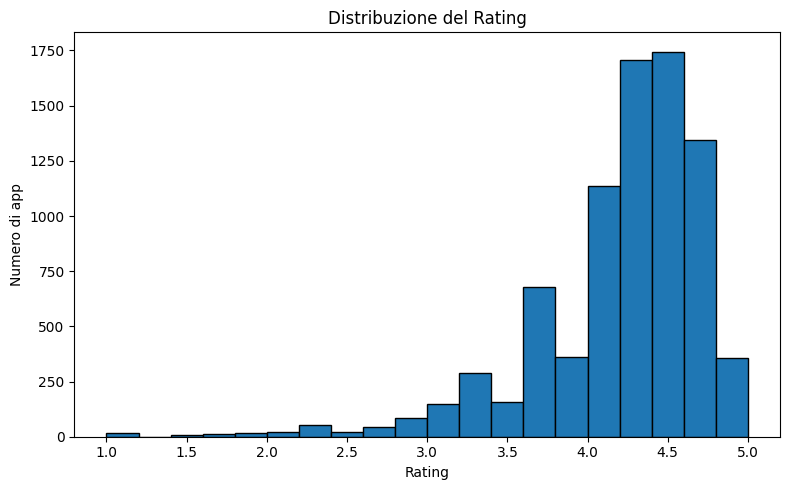

In [11]:
plot_histogram(
    apps["Rating"],
    bins=20,
    title="Distribuzione del Rating",
    xlabel="Rating",
    ylabel="Numero di app"
)

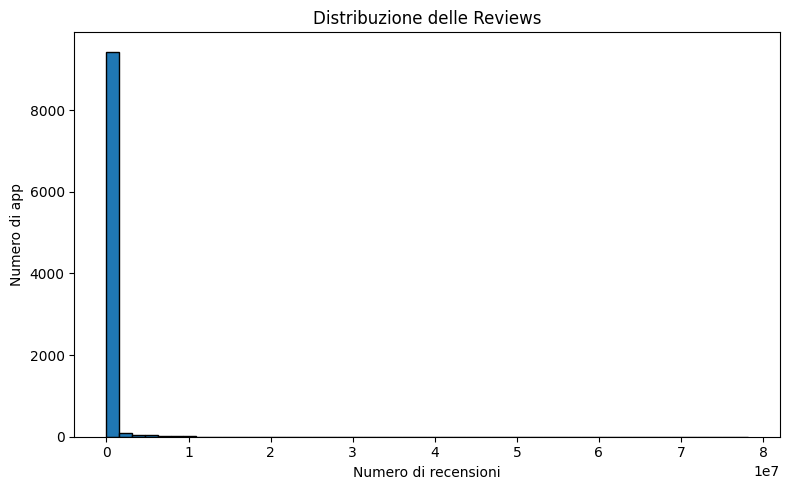

In [12]:
plot_histogram(
    series=apps["Reviews"],
    bins=50,
    title="Distribuzione delle Reviews",
    xlabel="Numero di recensioni",
    ylabel="Numero di app"
)

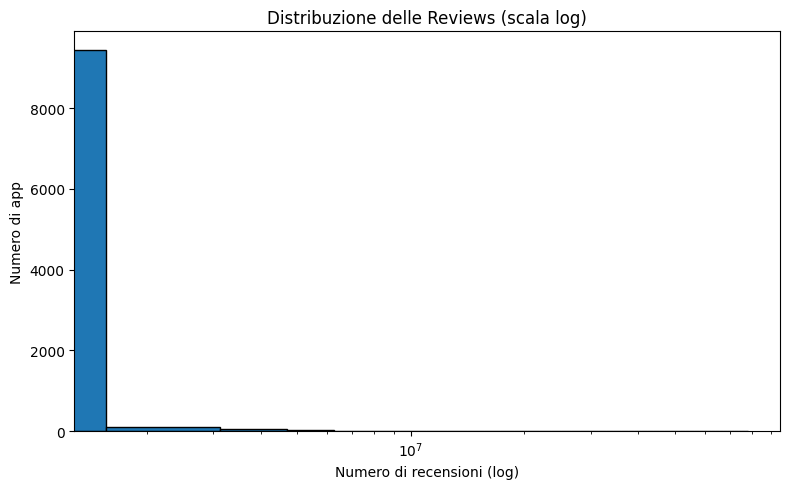

In [13]:
plot_histogram(
    series=apps["Reviews"],
    bins=50,
    title="Distribuzione delle Reviews (scala log)",
    xlabel="Numero di recensioni (log)",
    ylabel="Numero di app",
    log_x=True
)

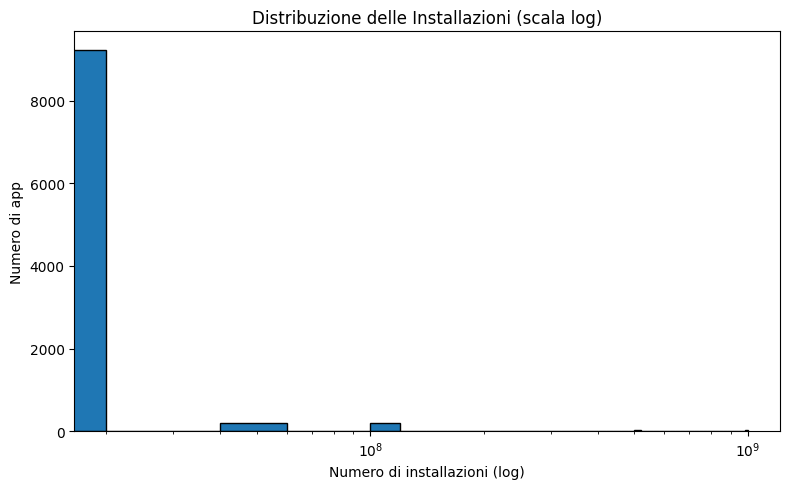

In [14]:
plot_histogram(
    series=apps["Installs"],
    bins=50,
    title="Distribuzione delle Installazioni (scala log)",
    xlabel="Numero di installazioni (log)",
    ylabel="Numero di app",
    log_x=True
)

Anche adottando una scala logaritmica, le distribuzioni di **Reviews** e **Installs** risultano fortemente sbilanciate, evidenziando una netta concentrazione di applicazioni con **valori bassi** e una **lunga coda** di pochi casi estremi.

In [15]:
apps["Category"].value_counts()


Category
FAMILY                 1875
GAME                    945
TOOLS                   829
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  170
VIDEO_PLAYERS           164
MAPS_AND_NAVIGATION     131
FOOD_AND_DRINK          112
EDUCATION               107
ENTERTAINMENT            87
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           73
EVENTS                   64
ART_AND_DESIGN           61
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [16]:
apps.groupby("Category")["Installs"].mean().sort_values(ascending=False)


Category
COMMUNICATION          3.504215e+07
VIDEO_PLAYERS          2.397502e+07
SOCIAL                 2.296179e+07
PHOTOGRAPHY            1.657704e+07
PRODUCTIVITY           1.548955e+07
GAME                   1.423061e+07
TRAVEL_AND_LOCAL       1.321866e+07
ENTERTAINMENT          1.137540e+07
TOOLS                  9.774152e+06
NEWS_AND_MAGAZINES     9.327629e+06
BOOKS_AND_REFERENCE    7.504367e+06
SHOPPING               6.932420e+06
WEATHER                4.570893e+06
PERSONALIZATION        4.075784e+06
HEALTH_AND_FITNESS     3.972300e+06
MAPS_AND_NAVIGATION    3.841846e+06
SPORTS                 3.373768e+06
FAMILY                 3.323489e+06
FOOD_AND_DRINK         1.891060e+06
ART_AND_DESIGN         1.856362e+06
EDUCATION              1.775252e+06
BUSINESS               1.659916e+06
LIFESTYLE              1.365375e+06
HOUSE_AND_HOME         1.331541e+06
FINANCE                1.319851e+06
DATING                 8.289712e+05
COMICS                 8.032348e+05
LIBRARIES_AND_DEMO 

In [17]:
apps.groupby("Category")["Installs"].median().sort_values(ascending=False)


Category
EDUCATION              1000000.0
SHOPPING               1000000.0
ENTERTAINMENT          1000000.0
GAME                   1000000.0
PHOTOGRAPHY            1000000.0
VIDEO_PLAYERS          1000000.0
WEATHER                1000000.0
HOUSE_AND_HOME          500000.0
FOOD_AND_DRINK          300000.0
ART_AND_DESIGN          100000.0
PARENTING               100000.0
MAPS_AND_NAVIGATION     100000.0
PRODUCTIVITY            100000.0
HEALTH_AND_FITNESS      100000.0
AUTO_AND_VEHICLES       100000.0
COMICS                  100000.0
COMMUNICATION           100000.0
TRAVEL_AND_LOCAL        100000.0
SOCIAL                  100000.0
SPORTS                  100000.0
NEWS_AND_MAGAZINES       50000.0
FAMILY                   50000.0
BEAUTY                   50000.0
TOOLS                    50000.0
BOOKS_AND_REFERENCE      10000.0
LIFESTYLE                10000.0
PERSONALIZATION          10000.0
DATING                   10000.0
FINANCE                  10000.0
LIBRARIES_AND_DEMO       10000.0
B

L’analisi per **categoria** mostra come alcune aree presentino un’elevata concentrazione di applicazioni, mentre altre evidenziano un buon livello di interesse degli utenti pur mantenendo una concorrenza più contenuta.

In [18]:
category_summary = apps.groupby("Category").agg(
    app_count=("App", "count"),
    median_installs=("Installs", "median")
).reset_index()

category_summary.head()


,Category,app_count,median_installs
0,ART_AND_DESIGN,61,100000.0
1,AUTO_AND_VEHICLES,85,100000.0
2,BEAUTY,53,50000.0
3,BOOKS_AND_REFERENCE,222,10000.0
4,BUSINESS,420,1000.0


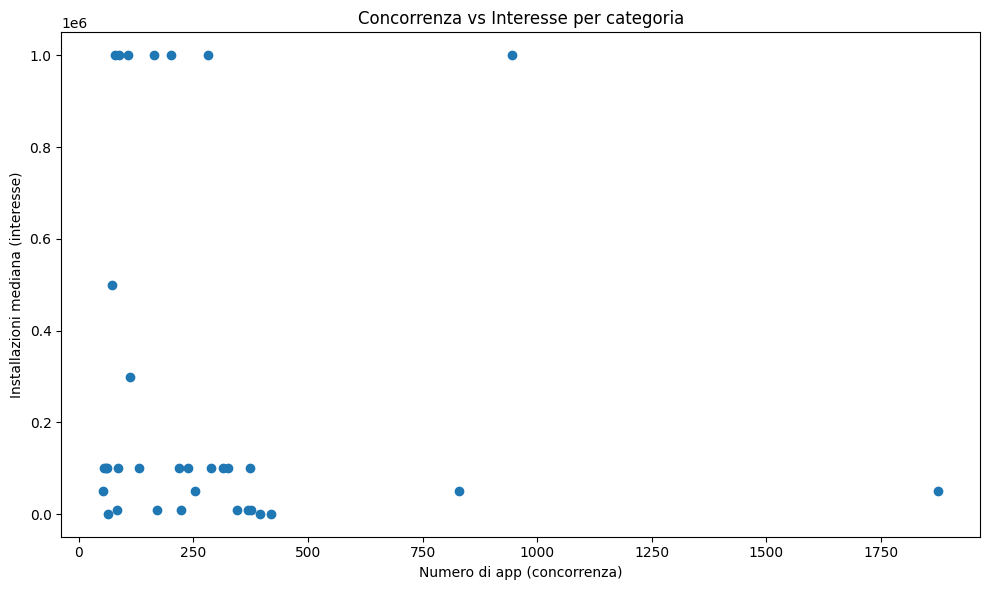

In [19]:
plot_scatter(
    x=category_summary["app_count"],
    y=category_summary["median_installs"],
    title="Concorrenza vs Interesse per categoria",
    xlabel="Numero di app (concorrenza)",
    ylabel="Installazioni mediana (interesse)"
)

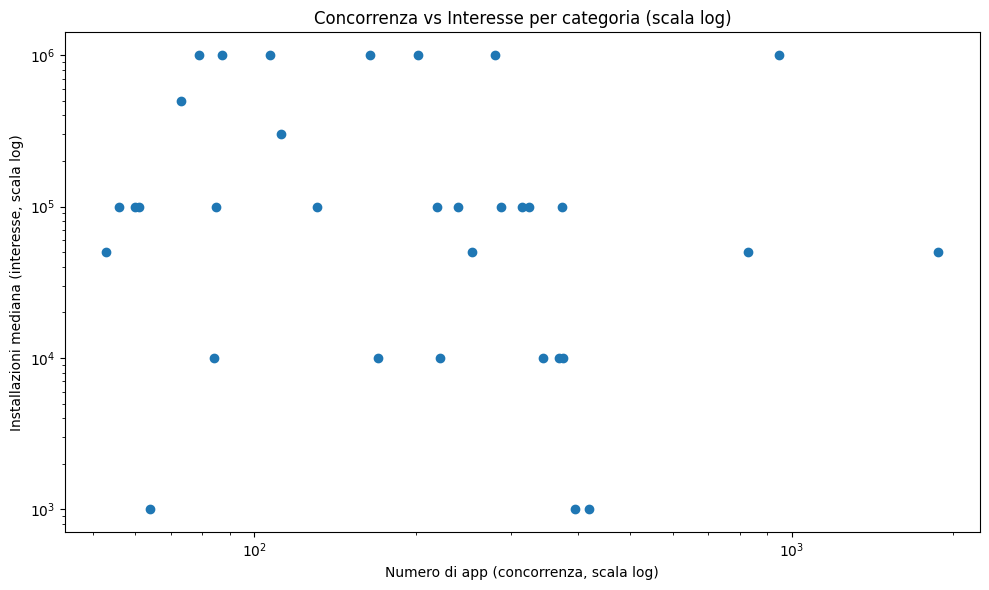

In [20]:
plot_scatter(
    x=category_summary["app_count"],
    y=category_summary["median_installs"],
    title="Concorrenza vs Interesse per categoria (scala log)",
    xlabel="Numero di app (concorrenza, scala log)",
    ylabel="Installazioni mediana (interesse, scala log)",
    log_x=True,
    log_y=True
)

Il **confronto** tra livello di concorrenza e interesse degli utenti mostra come alcune categorie si collochino in una posizione **favorevole**, caratterizzata da una domanda significativa a fronte di una concorrenza relativamente contenuta. Tali categorie rappresentano potenziali aree di **opportunità** per lo sviluppo di una nuova applicazione.

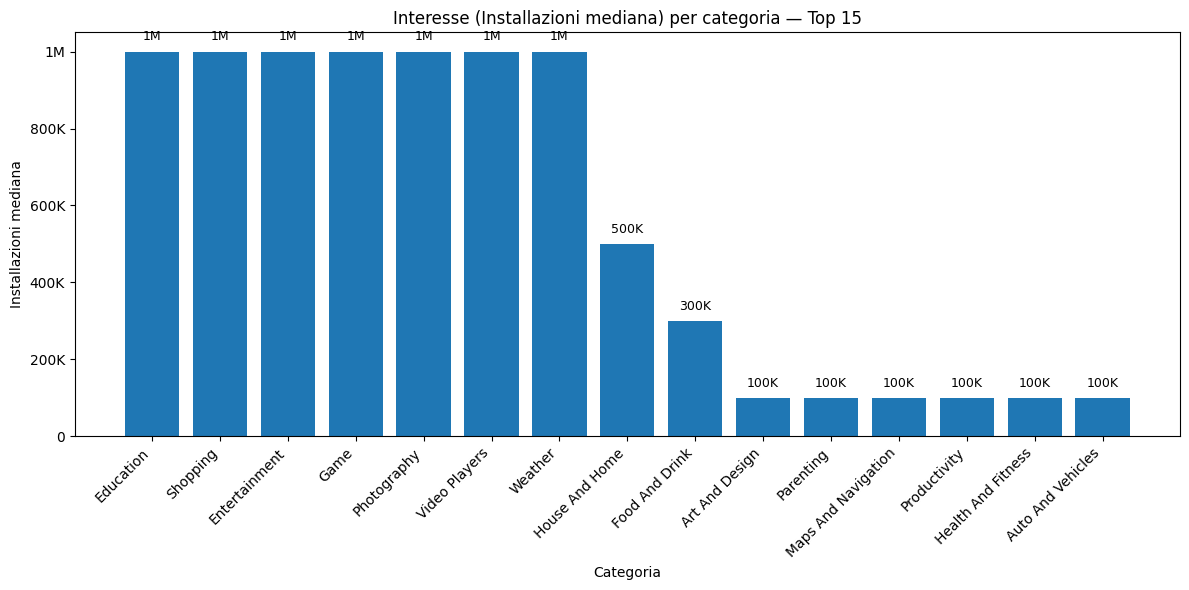

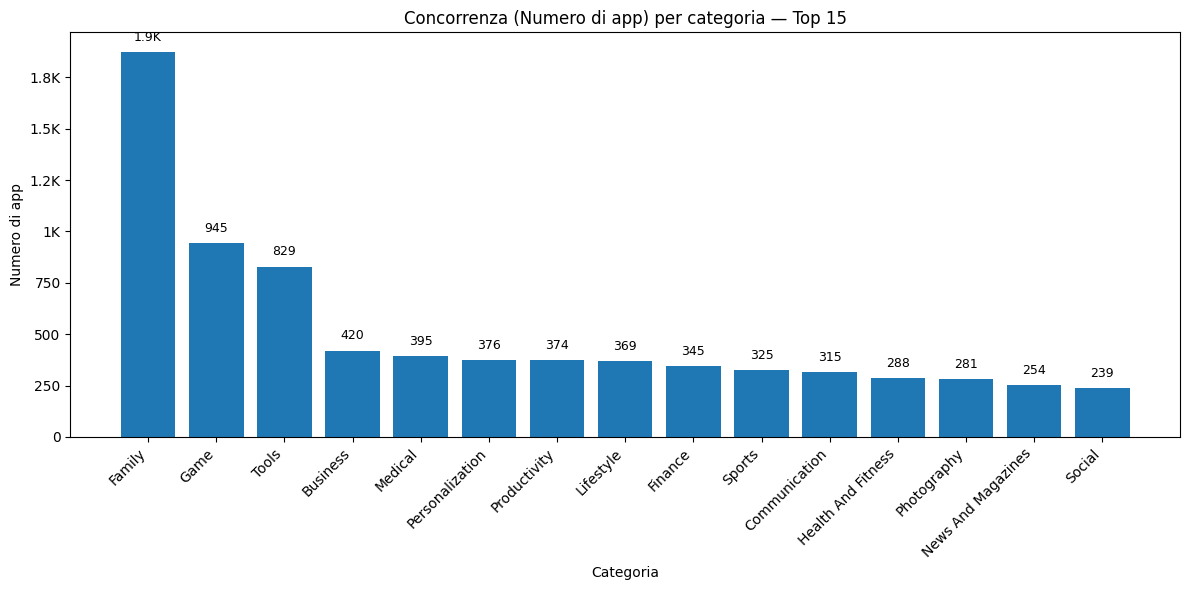

In [48]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- helper formatter---
def short_num(x, pos=None):
    x = float(x)

    if x >= 1_000_000:
        val = x / 1_000_000
        return f"{val:.1f}M" if val % 1 != 0 else f"{int(val)}M"

    if x >= 1_000:
        val = x / 1_000
        return f"{val:.1f}K" if val % 1 != 0 else f"{int(val)}K"

    return f"{int(x)}"


# --- crea summary se non esiste già (non fa male se esiste) ---
category_summary = (
    apps
    .groupby("Category", as_index=False)
    .agg(
        app_count=("App", "count") if "App" in apps.columns else ("Category", "size"),
        median_installs=("Installs", "median")
    )
)

# --- ordina per interesse ---
sorted_summary = category_summary.sort_values("median_installs", ascending=False).copy()

# --- pulisci label categorie ---
sorted_summary["Category"] = (
    sorted_summary["Category"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# --- (opzionale) limita a Top N per leggibilità ---
TOP_N = 15
sorted_top = sorted_summary.head(TOP_N).copy()

# ========== GRAFICO 1: INTERESSE ==========
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_top["Category"], sorted_top["median_installs"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Interesse (Installazioni mediana) per categoria — Top {TOP_N}")
plt.xlabel("Categoria")
plt.ylabel("Installazioni mediana")

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(short_num))

# etichette sopra le barre (brevi)
ymax = ax.get_ylim()[1] if ax.get_ylim()[1] else 1
for b in bars:
    val = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        val + ymax * 0.02,
        short_num(val),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ========== GRAFICO 2: CONCORRENZA ==========
# Ordino per concorrenza (così ha senso anche questo grafico)
sorted_comp = category_summary.sort_values("app_count", ascending=False).copy()
sorted_comp["Category"] = (
    sorted_comp["Category"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)
sorted_comp_top = sorted_comp.head(TOP_N).copy()

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_comp_top["Category"], sorted_comp_top["app_count"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Concorrenza (Numero di app) per categoria — Top {TOP_N}")
plt.xlabel("Categoria")
plt.ylabel("Numero di app")

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(short_num))

ymax = ax.get_ylim()[1] if ax.get_ylim()[1] else 1
for b in bars:
    val = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        val + ymax * 0.02,
        short_num(val),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

L'interesse degli utenti domina in **Education**, **Shopping** ed **Entertainment**, ma i grafici confermano che volumi alti non garantiscono vita facile: la saturazione in **Family**, **Game** e **Tools** è brutale. La mossa vincente è puntare a categorie con un'ottima mediana di installazioni schivando però i segmenti dove la folla è troppa per farsi notare.

### Correlazione tra Rating e popolarità (Installs)
Per capire se le app più installate tendono anche ad avere rating più alti, calcolo la correlazione tra **Rating** e **Installs**.  
Userò sia **Pearson** (relazione lineare) sia **Spearman** (relazione “monotona”, più robusta quando i dati non sono lineari o hanno outlier).

In [49]:
import numpy as np

# prendo solo righe valide
corr_df = apps.dropna(subset=["Rating", "Installs"]).copy()

# Installs è super “skewed”: uso log per rendere il grafico più leggibile
corr_df["log_installs"] = np.log1p(corr_df["Installs"])

pearson = corr_df[["Rating", "log_installs"]].corr(method="pearson").iloc[0, 1]
spearman = corr_df[["Rating", "log_installs"]].corr(method="spearman").iloc[0, 1]

print(f"Pearson (Rating vs log(Installs+1)):  {pearson:.3f}")
print(f"Spearman (Rating vs log(Installs+1)): {spearman:.3f}")

Pearson (Rating vs log(Installs+1)):  0.085
Spearman (Rating vs log(Installs+1)): 0.027


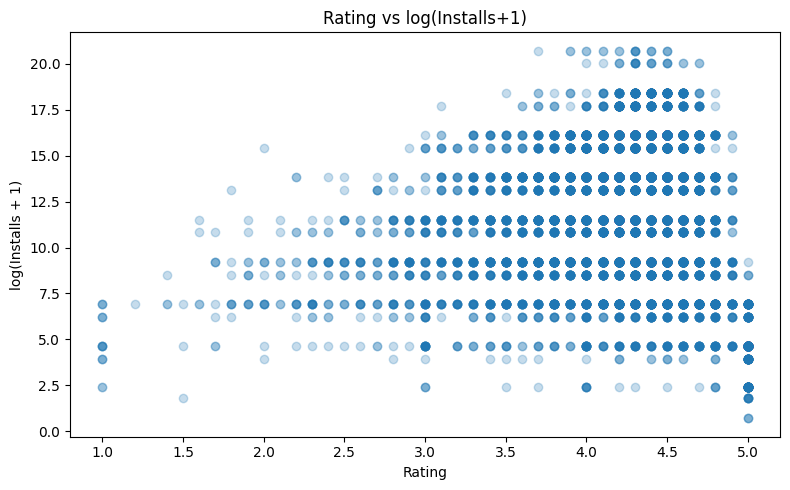

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(corr_df["Rating"], corr_df["log_installs"], alpha=0.25)

plt.title("Rating vs log(Installs+1)")
plt.xlabel("Rating")
plt.ylabel("log(Installs + 1)")
plt.tight_layout()
plt.show()

### Interpretazione:
L’analisi della relazione tra **Rating** e **Installazioni** **(in scala logaritmica)** mostra una tendenza positiva: in generale, al crescere del rating aumentano anche le installazioni. Tuttavia, la dispersione dei punti indica che la relazione non è perfettamente lineare.
Il coefficiente di **Pearson** misura la correlazione lineare e può essere influenzato dalla distribuzione non uniforme delle installazioni. Il coefficiente di **Spearman**, basato sui ranghi, risulta più adatto in questo caso perché cattura meglio relazioni monotone anche non strettamente lineari.

In sintesi: esiste una relazione tra qualità percepita (rating) e successo (installazioni), ma il rating da solo non spiega completamente il volume di download. Questo rafforza l’idea che fattori come categoria, visibilità e modello di business giochino un ruolo determinante.

---

## Dalla scelta della categoria al bisogno reale: perché “Lifestyle” e perché Eurobarometer 388

Sulla base dell’analisi condotta, la categoria **Lifestyle** emerge come una possibile area di opportunità per lo sviluppo di una nuova applicazione a tema sostenibilità. Questa categoria presenta infatti un equilibrio interessante tra **livello di concorrenza** e **interesse degli utenti**, risultando adatta a un progetto pensato per incastrare **diffusione**, **impatto ambientale** e **sostenibilità economica**.

Dall’analisi del dataset emerge inoltre come le applicazioni con il maggior numero di installazioni siano prevalentemente **gratuite**. Questo suggerisce che un modello **free** o **freemium** rappresenti la scelta più efficace per spingere un’adozione iniziale ampia: in un contesto fortemente competitivo come quello del Google Play Store, ridurre le barriere all’ingresso è cruciale per attrarre nuovi utenti e costruire una base solida fin dalle prime fasi di lancio.

In linea con la categoria Lifestyle e con il modello di business adottato, l’app dovrebbe concentrarsi sulla **riduzione degli sprechi** e sul **miglioramento delle abitudini quotidiane**: non una “wiki da sfogliare”, ma uno strumento **interattivo** che accompagna le persone nelle scelte reali di ogni giorno.

L’app potrebbe includere anche elementi molto concreti come:

•**Il monitoraggio delle abitudini di consumo**, aiutando gli utenti a prendere maggiore consapevolezza delle proprie scelte quotidiane;

•**Strumenti di supporto alla riduzione degli sprechi**, ad esempio attraverso suggerimenti pratici per il riutilizzo dei prodotti o una migliore pianificazione degli acquisti;

•**Feedback visivo sull’impatto delle azioni**, mostrando in modo semplice come determinate scelte possano contribuire a un uso più responsabile delle risorse.

•**Promemoria personalizzati** (es. reminder per giorni di raccolta, o per controllare cosa sta “per scadere” in casa);

•**Scanner etichette / Simboli di riciclo**, per capire rapidamente dove buttare un imballaggio e come separarlo correttamente;

•**Checklist e obiettivi settimanali** (piccoli step, non missioni impossibili) con progressi visibili;

•**Mappa di punti utili** (isole ecologiche, raccolta RAEE, punti di conferimento) e, dove presenti, sistemi di incentivi/punti (esterni, come per esempio i punti del supermecato) legati al riciclo.

•**Sistema di punti interno e community**, così da incentivare l'uso dell'app e la connessione alla sostenibilità.

A questo punto, però, per progettare un’app credibile serve validare una cosa fondamentale: **il bisogno è davvero percepito dalle persone?** E dove ci sono più margini di miglioramento?  
Per rispondere in modo data-driven, ho integrato l’analisi con il dataset **Flash Eurobarometer 388** (link: https://webgate.ec.europa.eu/eurobarometer/api/public/odp/download?key=A5643BCE9DB6B07020F75A32D887B2FB), un’indagine a livello europeo che permette di osservare **comportamenti**, **percezioni**, **barriere** e **gap informativi** legati a riciclo, sprechi e scelte di consumo.

In pratica: il dataset europeo è perfetto per dimostrare non solo l’utilità dell’app, ma anche la presenza di un **mercato potenziale** (persone interessate, ma che spesso non sanno bene *come* agire o non riescono a farlo in modo costante).

In [22]:
q42 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q4.2", header=None)

# parse tabella
header_row = 8
q42_table = q42.copy()
q42_table.columns = q42_table.iloc[header_row]
q42_table = q42_table.iloc[header_row+1:].reset_index(drop=True)

# estrazione righe INGLESI con percentuali
label_series = q42_table.iloc[:, 1].astype(str)
value_series = pd.to_numeric(q42_table.iloc[:, 2], errors="coerce")

labels_en = [
    "Totally agree",
    "Tend to agree",
    "Tend to disagree",
    "Totally disagree"
]

mask = label_series.isin(labels_en)

q42_eu = pd.DataFrame({
    "response": label_series[mask].values,
    "EU28": value_series[mask].values
}).set_index("response")

q42_eu


,EU28
response,
Totally agree,0.15
Tend to agree,0.28
Tend to disagree,0.34
Totally disagree,0.22


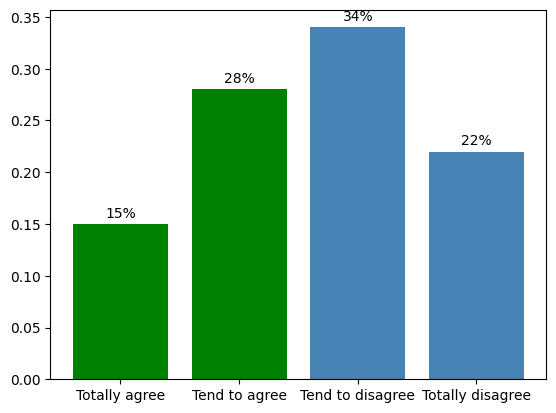

In [23]:
order = ["Totally agree", "Tend to agree", "Tend to disagree", "Totally disagree"]
q42_plot = q42_eu.loc[order].copy()

# Colori
colors = ["green", "green", "steelblue", "steelblue"]

# Calcolo totali
agree_total = q42_plot.loc["Totally agree", "EU28"] + q42_plot.loc["Tend to agree", "EU28"]
disagree_total = q42_plot.loc["Tend to disagree", "EU28"] + q42_plot.loc["Totally disagree", "EU28"]

# Grafico
bars = plt.bar(q42_plot.index, q42_plot["EU28"], color=colors)
add_bar_labels(bars, as_percent=True)

Il **grafico** evidenzia come una parte significativa della popolazione europea riconosca che la propria famiglia produce **troppi rifiuti**. Il fatto che il **43%** degli intervistati si dichiari d’accordo o totalmente d’accordo indica che il problema della gestione dei rifiuti domestici è percepito come **reale** e legato alle abitudini quotidiane. Questa consapevolezza rappresenta un **potenziale interesse** verso strumenti pratici in grado di aiutare le persone a migliorare la gestione dei rifiuti all’interno delle proprie case.

In [24]:
q6 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q6", header=None)

# Individuo la riga header
header_row = q6[q6.apply(lambda row: row.astype(str).str.contains("UE28", case=False).any(), axis=1)].index[0]

# Costruisco tabella pulita
q6_table = q6.copy()
q6_table.columns = q6_table.iloc[header_row]
q6_table = q6_table.iloc[header_row+1:].reset_index(drop=True)

q6_table.head(17)


8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,26595,1000,1000,1000,1008,1000,1000,1000,...,1001,1001,1002,1025,1023,1003,1005,1000,1007,1005
1,NaN,Le papier/ le carton / les briques de boissons,23846,972,637,922,797,978,847,950,...,987,861,909,514,900,925,927,940,942,762
2,NaN,Paper / Cardboard / Beverage cartons,0.9,0.97,0.64,0.92,0.79,0.98,0.85,0.95,...,0.99,0.86,0.91,0.5,0.88,0.92,0.92,0.94,0.94,0.76
3,NaN,Les bouteilles en plastique et autres matériau...,23901,966,662,960,762,959,879,941,...,940,911,899,611,930,932,819,946,939,897
4,NaN,Plastic bottles or other plastic materials,0.9,0.97,0.66,0.96,0.76,0.96,0.88,0.94,...,0.94,0.91,0.9,0.6,0.91,0.93,0.81,0.95,0.93,0.89
5,NaN,Les boîtes et canettes en métal,20817,943,503,556,743,854,740,883,...,902,825,826,357,851,607,861,903,898,587
6,NaN,Metal cans,0.78,0.94,0.5,0.56,0.74,0.85,0.74,0.88,...,0.9,0.82,0.82,0.35,0.83,0.61,0.86,0.9,0.89,0.58
7,NaN,Le verre,23330,971,582,920,918,976,750,914,...,960,871,911,400,896,884,890,971,872,644
8,NaN,Glass,0.88,0.97,0.58,0.92,0.91,0.98,0.75,0.91,...,0.96,0.87,0.91,0.39,0.88,0.88,0.89,0.97,0.87,0.64
9,NaN,Les déchets de cuisine,19577,830,471,657,525,861,695,795,...,836,704,807,360,893,659,774,757,786,511


In [25]:
waste_type = q6_table.iloc[:, 1].astype(str).str.replace("\u00a0", " ", regex=False).str.strip()
eu_values  = pd.to_numeric(q6_table.iloc[:, 2], errors="coerce")

# Creo la tabella base e tolgo righe vuote
q6_eu = pd.DataFrame({"Waste type": waste_type, "EU28": eu_values}).dropna()

# Tengo solo righe “testuali” pulite (in inglese)
q6_eu = q6_eu[q6_eu["Waste type"].str.match(r"^[A-Za-z0-9 /(),.\-']+$", na=False)]

# Filtro solo le voci rilevanti
keywords = ["paper", "plastic", "glass", "metal", "kitchen", "garden", "hazardous", "electrical", "electronic"]
q6_eu = q6_eu[q6_eu["Waste type"].str.lower().apply(lambda s: any(k in s for k in keywords))]

# Rimuovo duplicati tenendo il valore massimo
q6_eu = q6_eu.groupby("Waste type", as_index=False)["EU28"].max()

# Ordino per percentuale (dal meno riciclato al più riciclato)
q6_eu = q6_eu.sort_values("EU28", ascending=True).reset_index(drop=True)

q6_eu

,Waste type,EU28
0,Garden waste,0.57
1,Kitchen waste,0.74
2,Electrical and electronic waste,0.76
3,Metal cans,0.78
4,"Household hazardous waste (paint, chemicals, b...",0.79
5,Glass,0.88
6,Paper / Cardboard / Beverage cartons,0.90
7,Plastic bottles or other plastic materials,0.90


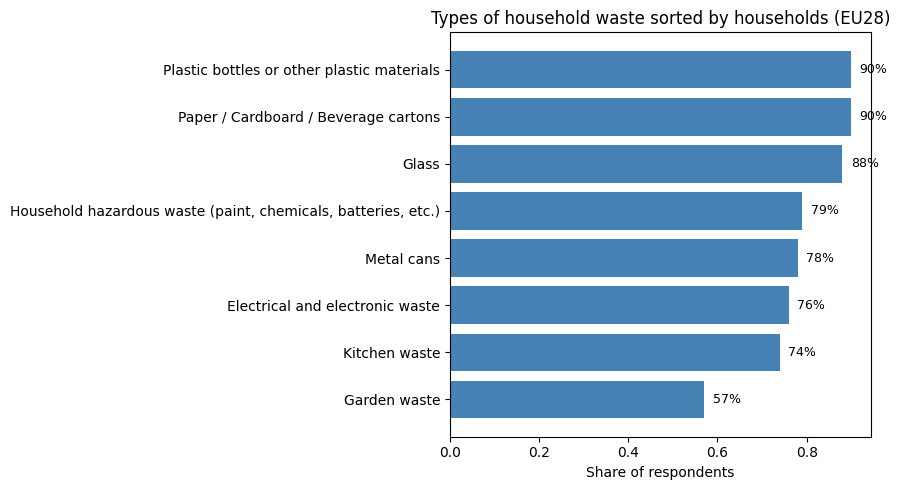

In [26]:
# Grafico
plt.figure(figsize=(9, 5))
bars = plt.barh(q6_eu["Waste type"], q6_eu["EU28"], color="steelblue")
plt.xlabel("Share of respondents")
plt.title("Types of household waste sorted by households (EU28)")

add_bar_labels_horizontal(bars, as_percent=True, fontsize=9, pad=0.02)

plt.tight_layout()
plt.show()

Le persone riciclano, ma **non** in modo sistematico o completo. 
Mentre materiali comuni come carta, plastica e vetro vengono gestiti correttamente dalla maggioranza degli utenti, altre categorie, come rifiuti organici, elettronici e pericolosi, **restano indietro**.
Questo **squilibrio** suggerisce che il riciclo domestico diventa più fragile quando richiede conoscenze specifiche o azioni meno immediate. Ciò indica un buon **margine di miglioramento!**

In [27]:
q5a = pd.read_excel("FL388 Volume A.xls", sheet_name="Q5a", header=None)

# Individuo la riga header
header_row = q5a[q5a.apply(
    lambda row: row.astype(str).str.contains("UE28", case=False).any(),
    axis=1
)].index[0]

# Costruisco tabella pulita
q5a_table = q5a.copy()
q5a_table.columns = q5a_table.iloc[header_row]
q5a_table = q5a_table.iloc[header_row + 1:].reset_index(drop=True)

q5a_table.head(17)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,24660,949,934,914,803,942,879,967,...,932,914,938,955,954,912,924,911,964,911
1,NaN,Vous évitez le gaspillage de nourriture ou d’a...,20565,850,791,817,605,793,626,758,...,818,739,888,692,636,732,777,592,823,566
2,NaN,You avoid food waste and other types of waste ...,0.83,0.9,0.85,0.89,0.75,0.84,0.71,0.78,...,0.88,0.81,0.95,0.72,0.67,0.8,0.84,0.65,0.85,0.62
3,NaN,Vous évitez d’acheter des produits « suremball...,15294,600,558,436,369,676,391,640,...,665,640,708,458,514,574,612,450,641,379
4,NaN,You avoid buying ‘over packaged’ goods,0.62,0.63,0.6,0.48,0.46,0.72,0.45,0.66,...,0.71,0.7,0.75,0.48,0.54,0.63,0.66,0.49,0.66,0.42
5,NaN,Vous avez pris les mesures nécessaires pour ne...,13481,441,471,439,375,620,363,466,...,438,424,604,290,320,318,452,501,685,251
6,NaN,You have made an effort to stop receiving unwa...,0.55,0.47,0.5,0.48,0.47,0.66,0.41,0.48,...,0.47,0.46,0.64,0.3,0.34,0.35,0.49,0.55,0.71,0.28
7,NaN,Vous pratiquez le compostage à domicile,10789,504,241,554,366,519,455,502,...,618,417,381,245,535,488,525,485,418,368
8,NaN,You undertake home composting,0.44,0.53,0.26,0.61,0.46,0.55,0.52,0.52,...,0.66,0.46,0.41,0.26,0.56,0.54,0.57,0.53,0.43,0.4
9,NaN,Vous utilisez des piles rechargeables,14719,655,413,638,446,655,358,581,...,580,538,574,387,450,569,444,591,618,346


In [28]:
action = q5a_table.iloc[:, 1].astype(str)
eu_values = pd.to_numeric(q5a_table.iloc[:, 2], errors="coerce")

q5a_raw = pd.DataFrame({
    "Action": action,
    "EU28": eu_values
}).dropna()

# Pulizia stringhe
q5a_raw["Action"] = (
    q5a_raw["Action"]
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

# Tengo SOLO valori percentuali
q5a_raw = q5a_raw[(q5a_raw["EU28"] > 0) & (q5a_raw["EU28"] <= 1)]

# Tengo SOLO righe inglesi
q5a_raw = q5a_raw[q5a_raw["Action"].str.startswith("You")]

# Rimuovo voci inutili
exclude_terms = ["DK/NA", "NSP", "TOTAL", "DO NOT READ OUT"]
for term in exclude_terms:
    q5a_raw = q5a_raw[~q5a_raw["Action"].str.contains(term, case=False, na=False)]

# Se duplicati, tengo il valore max
q5a_eu = q5a_raw.groupby("Action", as_index=False)["EU28"].max()

# Ordino dal comportamento MENO diffuso al PIÙ diffuso
q5a_rank = q5a_eu.sort_values("EU28", ascending=True).reset_index(drop=True)

q5a_rank

,Action,EU28
0,You undertake home composting,0.44
1,You have made an effort to stop receiving unwa...,0.55
2,You drink tap water to avoid packaging waste,0.59
3,You use rechargeable batteries,0.60
4,You avoid buying ‘over packaged’ goods,0.62
5,You donate/sell items for re-use,0.67
6,You make an effort to get broken appliances re...,0.77
7,You avoid food waste and other types of waste ...,0.83


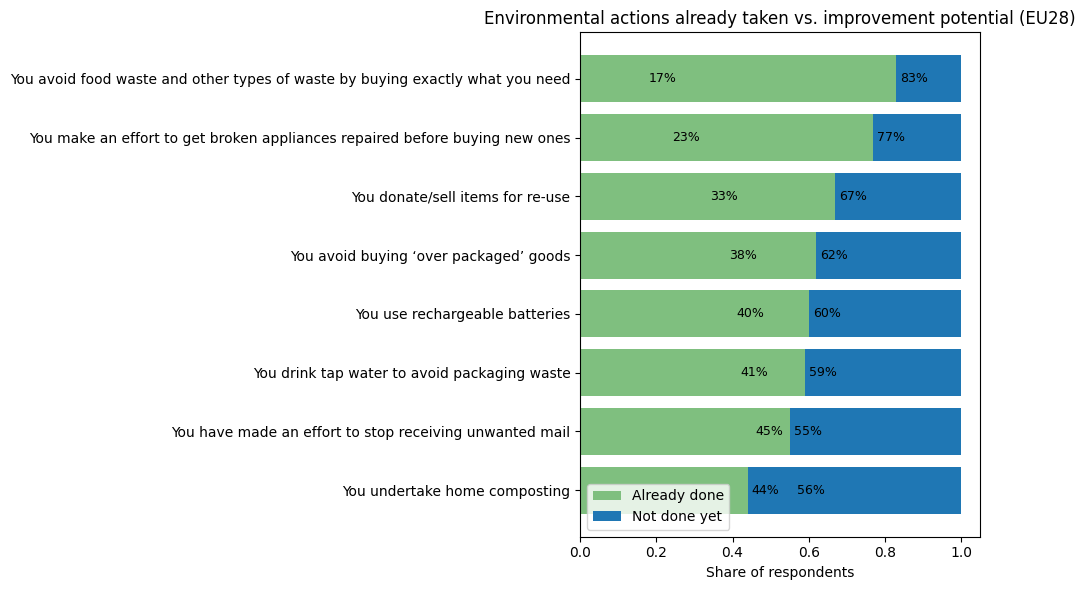

In [29]:
q5a_plot = q5a_rank.copy()
q5a_plot["Not done"] = 1 - q5a_plot["EU28"]

# Grafico
plt.figure(figsize=(10, 6))

bars_done = plt.barh(
    q5a_plot["Action"],
    q5a_plot["EU28"],
    color="#7FBF7F",
    label="Already done"
)

bars_not = plt.barh(
    q5a_plot["Action"],
    q5a_plot["Not done"],
    left=q5a_plot["EU28"],
    color="#1F77B4",
    label="Not done yet"
)

plt.xlabel("Share of respondents")
plt.title("Environmental actions already taken vs. improvement potential (EU28)")
plt.legend()

# etichette percentuali
add_bar_labels_horizontal(bars_done, as_percent=True, fontsize=9, pad=0.01)
add_bar_labels_horizontal(bars_not, as_percent=True, fontsize=9, pad=0.01)

plt.tight_layout()
plt.show()

**Nessuna** delle azioni analizzate raggiunge il **100%** di adozione, lasciando ampi spazi di miglioramento.
Questo suggerisce che un’app orientata a rendere queste pratiche più semplici e accessibili potrebbe avere un **impatto reale** sulle abitudini quotidiane degli utenti.

In [30]:
q5b = pd.read_excel("FL388 Volume A.xls", sheet_name="Q5b", header=None)

# Trovo la riga header
header_row = q5b[q5b.apply(
    lambda row: row.astype(str).str.contains("UE28", case=False).any(),
    axis=1
)].index[0]

# Imposto le colonne usando la riga header e taglio le righe sopra
q5b_table = q5b.copy()
q5b_table.columns = q5b_table.iloc[header_row]
q5b_table = q5b_table.iloc[header_row + 1:].reset_index(drop=True)

In [31]:
# Etichette e valori UE28
label_series = q5b_table.iloc[:, 1].astype(str)
value_series = pd.to_numeric(q5b_table.iloc[:, 2], errors="coerce")

# Seleziono la riga che inizia con "You don't know..."
mask = label_series.str.startswith("You don’t know") | label_series.str.startswith("You don't know")

# Creo la tabellina finale
q5b_row = pd.DataFrame({
    "Statement": label_series[mask].values,
    "EU28": value_series[mask].values
})

q5b_row

,Statement,EU28
0,You don’t know how you can reduce waste,0.3


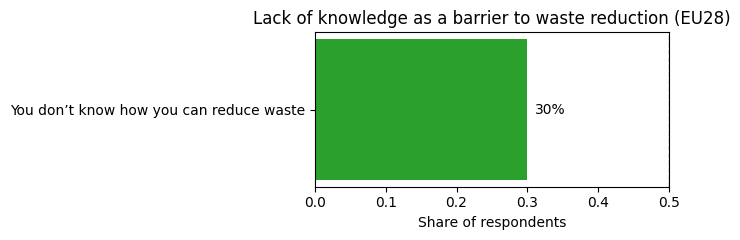

In [32]:
value = q5b_row["EU28"].iloc[0]

#Grafico
plt.figure(figsize=(7, 2.5))
bars = plt.barh(
    ["You don’t know how you can reduce waste"],
    [value],
    color="#2ca02c"
)

plt.xlabel("Share of respondents")
plt.title("Lack of knowledge as a barrier to waste reduction (EU28)")

plt.xlim(0, 0.5)
plt.axvline(0.5, linestyle="--", linewidth=1)

# etichette percentuali
add_bar_labels_horizontal(bars, as_percent=True, fontsize=10, pad=0.02)

plt.tight_layout()
plt.show()

Una quota piuttosto **rilevante** della popolazione europea dichiara di **non sapere** come ridurre i propri rifiuti.
Questo dimostra che il **vero ostacolo** è la mancanza di consigli pratici: un’app che offra indicazioni semplici e alla mano avrebbe quindi un **valore enorme**.

In [33]:
q13 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q13", header=None)

# Individuo la riga header
header_row = q13[q13.apply(
    lambda row: row.astype(str).str.contains("UE28", case=False).any(),
    axis=1
)].index[0]

# Costruisco tabella pulita
q13_table = q13.copy()
q13_table.columns = q13_table.iloc[header_row]
q13_table = q13_table.iloc[header_row + 1:].reset_index(drop=True)

q13_table.head(11)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,4299,180,243,184,117,125,164,133,...,141,137,167,409,213,257,81,76,111,247
1,NaN,Des préoccupations de santé et de sécurité,1779,76,108,88,23,59,36,47,...,59,57,61,200,25,127,31,28,60,72
2,NaN,Health and safety concerns,0.41,0.43,0.44,0.48,0.19,0.47,0.22,0.36,...,0.42,0.42,0.36,0.49,0.12,0.49,0.39,0.37,0.54,0.29
3,NaN,Une moins bonne qualité du produit,1858,76,110,104,40,53,81,50,...,58,51,75,201,68,138,38,30,57,106
4,NaN,Inferior quality of the product,0.43,0.42,0.45,0.56,0.34,0.43,0.5,0.38,...,0.41,0.37,0.45,0.49,0.32,0.54,0.46,0.39,0.51,0.43
5,NaN,L’apparence moins attirante du produit,838,49,35,54,19,33,18,12,...,34,43,51,60,8,69,19,14,29,22
6,NaN,Less appealing look of the product,0.2,0.27,0.14,0.29,0.16,0.27,0.11,0.09,...,0.24,0.32,0.31,0.15,0.04,0.27,0.23,0.19,0.26,0.09
7,NaN,Peur de ce que les autres pourraient penser de...,155,12,10,12,2,3,6,1,...,5,11,14,19,4,24,2,0,4,4
8,NaN,Afraid of what others might think of you,0.04,0.07,0.04,0.07,0.02,0.02,0.03,0.01,...,0.03,0.08,0.08,0.05,0.02,0.09,0.02,0.01,0.04,0.02
9,NaN,Vous n’y avez jamais pensé,880,45,35,41,42,19,25,23,...,25,33,53,60,81,52,17,14,19,65


In [34]:
barrier = q13_table.iloc[:, 1].astype(str)
eu_values = pd.to_numeric(q13_table.iloc[:, 2], errors="coerce")

q13_raw = pd.DataFrame({
    "Barrier": barrier,
    "EU28": eu_values
}).dropna()

# Pulizia stringhe
q13_raw["Barrier"] = (
    q13_raw["Barrier"]
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

# Tengo SOLO percentuali
q13_raw = q13_raw[(q13_raw["EU28"] > 0) & (q13_raw["EU28"] <= 1)]

# Tengo SOLO righe inglesi
q13_raw = q13_raw[q13_raw["Barrier"].str.match(r"^[A-Z]", na=False)]

# Rimuovo voci inutili
exclude_terms = ["DK/NA", "NSP", "TOTAL", "DO NOT READ OUT"]
for term in exclude_terms:
    q13_raw = q13_raw[~q13_raw["Barrier"].str.contains(term, case=False, na=False)]

# Se duplicati, tengo la percentuale corretta
q13_eu = q13_raw.groupby("Barrier", as_index=False)["EU28"].max()

# Top 5 barriere
q13_top5 = q13_eu.sort_values("EU28", ascending=False).head(5)

q13_top5

,Barrier,EU28
2,Inferior quality of the product,0.43
1,Health and safety concerns,0.41
3,Less appealing look of the product,0.20
4,Never thought of it,0.20
0,Afraid of what others might think of you,0.04


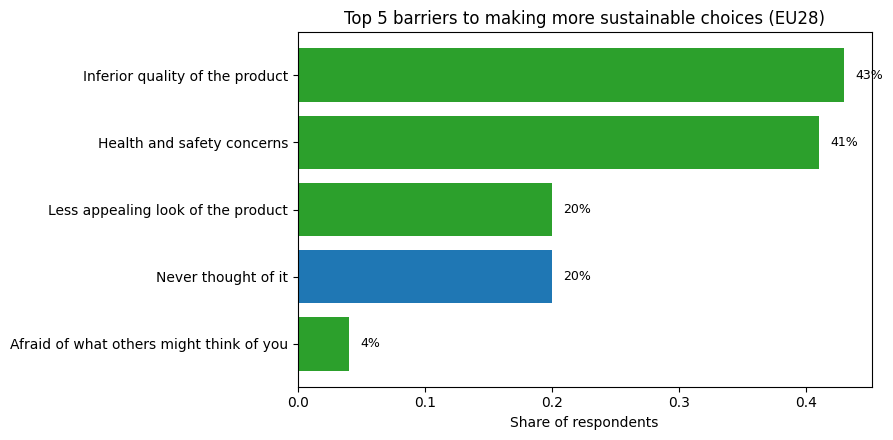

In [35]:
q13_plot = q13_top5.sort_values("EU28", ascending=True)

# Colori
colors = [
    "#1F77B4" if "Never thought of it" in barrier else "#2CA02C"
    for barrier in q13_plot["Barrier"]
]

# Grafico
plt.figure(figsize=(9, 4.5))
bars = plt.barh(q13_plot["Barrier"], q13_plot["EU28"], color=colors)

plt.xlabel("Share of respondents")
plt.title("Top 5 barriers to making more sustainable choices (EU28)")

# etichette percentuali
add_bar_labels_horizontal(bars, as_percent=True, fontsize=9, pad=0.02)

plt.tight_layout()
plt.show()

Tra le barriere considerate, risultano rilevanti sia **fattori percettivi**, come qualità e sicurezza dei prodotti, sia elementi **culturali** e **informativi**.
Questo suggerisce che una **guida digitale** potrebbe aiutare gli utenti a superare tali ostacoli, facilitando decisioni più consapevoli nelle scelte quotidiane.

In [36]:
q161 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q16.1", header=None)

# Individuo la riga header
header_row = q161[q161.apply(
    lambda row: row.astype(str).str.contains("UE28", case=False).any(),
    axis=1
)].index[0]

# Costruisco tabella pulita
q161_table = q161.copy()
q161_table.columns = q161_table.iloc[header_row]
q161_table = q161_table.iloc[header_row + 1:].reset_index(drop=True)

q161_table.head(15)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,26595,1000,1000,1000,1008,1000,1000,1000,...,1001,1001,1002,1025,1023,1003,1005,1000,1007,1005
1,NaN,Tout à fait d’accord,20206,713,859,670,771,730,655,780,...,725,709,848,861,821,741,722,816,752,816
2,NaN,Totally agree,0.76,0.71,0.86,0.67,0.76,0.73,0.65,0.78,...,0.72,0.71,0.85,0.84,0.8,0.74,0.72,0.82,0.75,0.81
3,NaN,Plutôt d’accord,4844,222,95,260,167,198,220,177,...,208,238,122,115,139,213,230,125,183,155
4,NaN,Tend to agree,0.18,0.22,0.1,0.26,0.17,0.2,0.22,0.18,...,0.21,0.24,0.12,0.11,0.14,0.21,0.23,0.12,0.18,0.15
5,NaN,Plutôt pas d’accord,813,37,9,50,38,39,59,18,...,41,18,12,11,30,31,30,29,40,15
6,NaN,Tend to disagree,0.03,0.04,0.01,0.05,0.04,0.04,0.06,0.02,...,0.04,0.02,0.01,0.01,0.03,0.03,0.03,0.03,0.04,0.02
7,NaN,Pas du tout d’accord,449,23,14,9,22,18,19,18,...,21,23,12,29,25,11,13,17,14,12
8,NaN,Totally disagree,0.02,0.02,0.01,0.01,0.02,0.02,0.02,0.02,...,0.02,0.02,0.01,0.03,0.02,0.01,0.01,0.02,0.01,0.01
9,NaN,NSP/ SR,283,5,23,11,10,15,47,6,...,7,12,9,8,8,6,10,13,19,6


In [37]:
labels = q161_table.iloc[:, 1].astype(str)
values = pd.to_numeric(q161_table.iloc[:, 2], errors="coerce")

# Tengo solo le 4 risposte standard
mask = (
    labels.str.contains("Totally agree", case=False, na=False) |
    labels.str.contains("Tend to agree", case=False, na=False) |
    labels.str.contains("Tend to disagree", case=False, na=False) |
    labels.str.contains("Totally disagree", case=False, na=False)
)

q161_eu = pd.DataFrame({
    "Response": labels[mask].values,
    "EU28": values[mask].values
}).set_index("Response")

q161_eu

,EU28
Response,
Totally agree,0.76
Tend to agree,0.18
Tend to disagree,0.03
Totally disagree,0.02


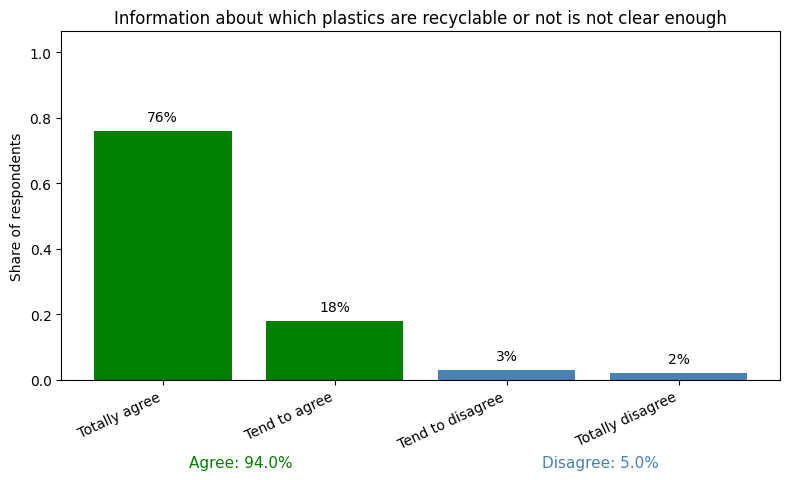

In [38]:
order = ["Totally agree", "Tend to agree", "Tend to disagree", "Totally disagree"]
q161_plot = q161_eu.loc[order].copy()

# Colori
colors = ["green", "green", "steelblue", "steelblue"]

agree_total = q161_plot.loc["Totally agree", "EU28"] + q161_plot.loc["Tend to agree", "EU28"]
disagree_total = q161_plot.loc["Tend to disagree", "EU28"] + q161_plot.loc["Totally disagree", "EU28"]

# Grafico
plt.figure(figsize=(8, 5))
bars = plt.bar(q161_plot.index, q161_plot["EU28"], color=colors)

plt.ylabel("Share of respondents")
plt.title("Information about which plastics are recyclable or not is not clear enough")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, q161_plot["EU28"].max() * 1.4)

# etichette sulle barre
add_bar_labels_vertical(bars, as_percent=True, fontsize=10, pad=0.02)

# testo sotto
plt.text(0.25, -0.25, f"Agree: {agree_total*100:.1f}%", color="green",
         fontsize=11, ha="center", transform=plt.gca().transAxes)
plt.text(0.75, -0.25, f"Disagree: {disagree_total*100:.1f}%", color="steelblue",
         fontsize=11, ha="center", transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

L’**elevata** quota di accordo indica una percezione diffusa della **scarsa chiarezza** delle informazioni sull’impatto ambientale delle plastiche.
Per questo, un’app potrebbe quindi intervenire fornendo soluzioni pratiche, come guidare l’utente nello smaltimento degli imballaggi interpretando le etichette per lui.
In più, inserendo strumenti come la mappa dei centri di raccolta o dei programmi di incentivi locali, si renderebbe molto più semplice trasformare l'interesse degli utenti in **azioni concrete**.

In [39]:
d11 = pd.read_excel("FL388 Volume A.xls", sheet_name="D1.1", header=None)

# Individuo la riga header
header_row = d11[d11.apply(lambda row: row.astype(str).str.contains("UE28", case=False).any(), axis=1)].index[0]

# Costruisco tabella pulita
d11_table = d11.copy()
d11_table.columns = d11_table.iloc[header_row]
d11_table = d11_table.iloc[header_row + 1:].reset_index(drop=True)

In [40]:
d13 = pd.read_excel("FL388 Volume A.xls", sheet_name="D13", header=None)

# Individuo la riga header
header_row = d13[d13.apply(lambda row: row.astype(str).str.contains("UE28", case=False).any(), axis=1)].index[0]

# Costruisco tabella pulita
d13_table = d13.copy()
d13_table.columns = d13_table.iloc[header_row]
d13_table = d13_table.iloc[header_row + 1:].reset_index(drop=True)

In [41]:
d18 = pd.read_excel("FL388 Volume A.xls", sheet_name="D18", header=None)

# Individuo la riga header
header_row = d18[d18.apply(lambda row: row.astype(str).str.contains("UE28", case=False).any(), axis=1)].index[0]

# Costruisco tabella pulita
d18_table = d18.copy()
d18_table.columns = d18_table.iloc[header_row]
d18_table = d18_table.iloc[header_row + 1:].reset_index(drop=True)

In [42]:
#D1.1 Età
labels_col = d11_table.iloc[:, 1].astype(str).str.replace("\u00a0", " ", regex=False).str.strip()
values_col = pd.to_numeric(d11_table.iloc[:, 2], errors="coerce")

d11_tmp = pd.DataFrame({"label": labels_col, "value": values_col})

# righe percentuali (0–1)
perc_rows = d11_tmp[(d11_tmp["value"] >= 0) & (d11_tmp["value"] <= 1)].copy()

# label fascia = riga sopra
perc_rows["age_group"] = d11_tmp["label"].shift(1).loc[perc_rows.index].values

age_dist = (
    perc_rows[perc_rows["age_group"].isin(["15-24", "25-39", "40-54", "55+"])]
    .set_index("age_group")["value"]
    .reindex(["15-24", "25-39", "40-54", "55+"])
    .fillna(0)
)

# Helpers D13 / D18
def eu_series(table):
    labels = table.iloc[:, 1].astype(str).str.replace("\u00a0", " ", regex=False).str.strip()
    values = pd.to_numeric(table.iloc[:, 2], errors="coerce")
    s = pd.Series(values.values, index=labels.values).dropna()

    # tengo solo percentuali (0–1) e pulisco righe inutili
    s = s[(s > 0) & (s <= 1)]
    s = s[~s.index.str.contains("DK/NA|NSP|TOTAL|DO NOT READ OUT|Other|Autre", case=False, na=False)]
    return s

def pick_value_regex(s, pattern):
    m = s[s.index.str.contains(pattern, case=False, na=False, regex=True)]
    return float(m.max()) if len(m) else 0.0

#D13 Area
area = eu_series(d13_table)

large_town = pick_value_regex(area, r"\bLarge\s*town\b")
small_town = max(
    pick_value_regex(area, r"\bSmall\b"),
    pick_value_regex(area, r"\bMiddle\b"),
    pick_value_regex(area, r"\bSmall\s*/\s*middle\b")
)
rural = pick_value_regex(area, r"\bRural\b")

area_groups = pd.Series({
    "Large town": large_town,
    "Small/middle town": small_town,
    "Rural area": rural
})

#D18 Telefono
phone = eu_series(d18_table)

yes_phone = pick_value_regex(phone, r"^Yes\b")
no_phone  = pick_value_regex(phone, r"^No\b")

phone_groups = pd.Series({
    "Yes": yes_phone,
    "No": no_phone
})

# Debug + warning
print("age_dist:\n", age_dist, "\n")
print("area_groups:\n", area_groups, "\n")
print("phone_groups:\n", phone_groups, "\n")

if area_groups.sum() == 0:
    print("⚠️ WARNING: area_groups è tutto 0 → controlla D13_table (probabile struttura 'conteggio+percentuale').")

if phone_groups.sum() == 0:
    print("⚠️ WARNING: phone_groups è tutto 0 → controlla D18_table (probabile struttura 'conteggio+percentuale').")

age_dist:
 age_group
15-24    0.14
25-39    0.25
40-54    0.26
55+      0.35
Name: value, dtype: float64 

area_groups:
 Large town           0.27
Small/middle town    0.40
Rural area           0.32
dtype: float64 

phone_groups:
 Yes    0.92
No     0.08
dtype: float64 



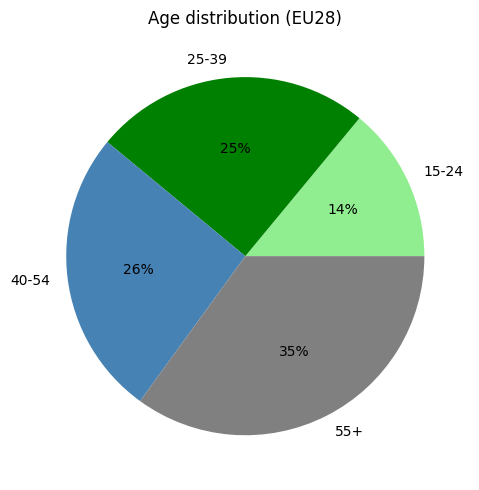

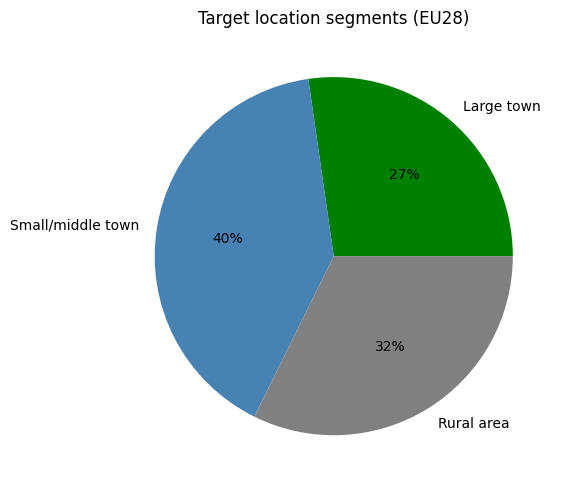

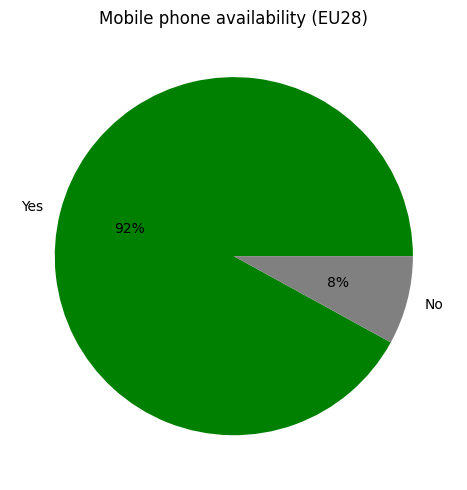

In [43]:
# Età pie
plt.figure(figsize=(6, 5))
plt.pie(
    age_dist.values,
    labels=age_dist.index,
    autopct=lambda p: f"{p:.0f}%",
    colors=["lightgreen", "green", "steelblue", "gray"]  # 15-24 & 25-39 verde
)
plt.title("Age distribution (EU28)")
plt.tight_layout()
plt.show()

# AREA pie
plt.figure(figsize=(6, 5))
plt.pie(
    area_groups.values,
    labels=area_groups.index,
    autopct=lambda p: f"{p:.0f}%",
    colors=["green", "steelblue", "gray"]
)
plt.title("Target location segments (EU28)")
plt.tight_layout()
plt.show()

# PHONE pie
plt.figure(figsize=(6, 5))
plt.pie(
    phone_groups.values,
    labels=phone_groups.index,
    autopct=lambda p: f"{p:.0f}%",
    colors=["green", "gray"]
)
plt.title("Mobile phone availability (EU28)")
plt.tight_layout()
plt.show()

I dati anagrafici mostrano chiaramente quanto sia **vasto** e **concreto** il pubblico che un’app per la sostenibilità può raggiungere.

In questa lettura, il colore 
<span style="color:green; font-weight:600;">verde</span> identifica i segmenti di popolazione più **facilmente raggiungibili** attraverso un’applicazione mobile, 
il <span style="color:steelblue; font-weight:600;">blu</span> quelli **moderatamente raggiungibili** 
e il <span style="color:gray; font-weight:600;">grigio</span> quelli **meno propensi** all’adozione di strumenti digitali di questo tipo.

Le fasce tra i **15** e i **39 anni** rappresentano il **target principale**: costituiscono una quota rilevante della popolazione e utilizzano lo smartphone quotidianamente. 
Al contrario, le fasce più anziane, pur potendo condividere alcune delle criticità emerse nelle analisi precedenti, risultano meno inclini all’utilizzo di un’app dedicata, riducendo l’efficacia di un intervento esclusivamente digitale.

Anche la distribuzione geografica conferma questa tendenza: una **parte significativa** della popolazione vive in contesti **urbani** o **semi-urbani**, dove l’uso di applicazioni digitali è più diffuso e dove servizi, punti di raccolta e iniziative legate alla sostenibilità risultano più facilmente integrabili con strumenti digitali.

Inoltre, **la quasi totalità** dei rispondenti dispone di un **telefono mobile**, rendendo tecnicamente possibile una diffusione ampia dell’app. 
Questo elemento conferma che le criticità emerse nelle sezioni precedenti non solo sono rilevanti, ma anche affrontabili attraverso una soluzione digitale accessibile.

Questo significa che i problemi emersi finora non sono solo reali, ma possono essere affrontati concretamente con uno **strumento accessibile**. 
In sintesi, i dati indicano che un’app per il riciclo e la riduzione degli sprechi può intercettare un **pubblico numeroso, digitalizzato** e **potenzialmente pronto** a modificare le proprie abitudini quotidiane.


## Sintesi finale: perché questa app ha senso (per utenti, ambiente e sostenibilità economica)

I risultati del **Flash Eurobarometer 388** rafforzano in modo netto l’idea di un’app Lifestyle orientata a ridurre sprechi e migliorare le abitudini quotidiane. I dati mostrano che il problema è reale, diffuso e — soprattutto — collegato a margini di miglioramento concreti.

**1) Il bisogno è percepito (e quindi “vendibile” come problema da risolvere).**  
Una quota significativa di cittadini europei riconosce che la gestione dei rifiuti domestici è un tema critico. Questo è importante perché, nel mercato app, se l’utente non sente il problema, non scarica niente.

**2) Il riciclo c’è, ma è incompleto: qui si gioca l’impatto.**  
Dalla domanda sui materiali riciclati emerge una grande differenza tra ciò che viene riciclato spesso e ciò che viene trascurato: ad esempio **garden waste (57%)** e **kitchen waste (74%)** restano indietro rispetto a **carta e plastica (90%)** e **vetro (88%)**.  
Questo suggerisce che l’app può generare valore puntando su categorie dove il comportamento è ancora “a metà”, con guide pratiche, reminder e istruzioni semplici.

**3) Le abitudini sostenibili non sono ancora universali: c’è spazio per migliorare.**  
Alcune azioni sono molto diffuse (es. evitare sprechi alimentari: **83%**), ma altre restano indietro (es. compost domestico: **44%**).  
Queste differenze mostrano una cosa chiave: non serve “convincere il mondo intero”, basta spostare una parte degli utenti su comportamenti migliori, perché l’impatto cumulativo è enorme.

**4) Il vero blocco è spesso informativo (e qui l’app diventa utile davvero).**  
Il dato più forte è che **il 94%** concorda sul fatto che le informazioni sull’impatto ambientale dei prodotti non siano abbastanza chiare.  
Questo è esattamente il punto in cui l’app smette di essere teoria e diventa pratica: scanner di etichette/simboli, istruzioni di smaltimento, alternative più sostenibili, e un “traduttore” immediato tra prodotto e azione.

**5) Anche quando esiste l’interesse, ci sono barriere che l’app può abbattere.**  
Sulle scelte di acquisto (es. seconda mano) emergono ostacoli legati a **qualità percepita (43%)** e **sicurezza/salute (41%)**, oltre a fattori come “non ci ho mai pensato” (20%).  
Qui l’app può intervenire con micro-educazione, guide e strumenti di fiducia (checklist, consigli, standard minimi, spiegazioni chiare), rendendo più facile adottare scelte sostenibili senza ansia o confusione.

**6) Mercato “raggiungibile”: i dati anagrafici lo confermano.**  
Il campione mostra un pubblico significativo nelle fasce 15–39 e una quota alta di persone con smartphone (**92%**). Questo rende realistico un modello basato su diffusione digitale: le evidenze sulle criticità emerse non restano “astratte”, perché esiste un bacino di utenti tecnicamente raggiungibile da un’app.

---

### Strategia di prodotto (Lifestyle, ma con strumenti pratici)
L’app può posizionarsi come un assistente quotidiano “anti-spreco” con tre pilastri operativi:
- **Guidare l’azione** (cosa faccio con questo rifiuto? dove lo butto? come lo separo?);
- **Rendere costante il comportamento** (reminder personalizzati, obiettivi settimanali, progressi);
- **Far capire l’impatto** (feedback visivo semplice, non lezioni infinite).

---

### Modello di business (free/freemium) sostenibile e coerente coi dati
Coerentemente con quanto emerso dal Google Play Store, la base dell’app dovrebbe essere **gratuita** per massimizzare la diffusione e ridurre l’attrito all’ingresso.  
La monetizzazione può avvenire con un livello **premium opzionale**, focalizzato su valore reale (non paywall aggressivi), ad esempio:
- statistiche avanzate e report personalizzati;
- piani e reminder evoluti (famiglia/casa condivisa);
- strumenti di monitoraggio a lungo termine e obiettivi personalizzati;
- funzioni “pro” per utenti motivati (es. profili di consumo, suggerimenti più dettagliati).

In sintesi, i dati supportano l’idea che un’app Lifestyle orientata a riciclo e riduzione sprechi possa avere:
- **utilità reale** (perché i gap sono misurabili e diffusi),
- **adozione plausibile** (pubblico raggiungibile e smartphone diffusi),
- **potenziale economico** (free/freemium coerente con dinamiche di mercato e con bisogno percepito).